In [184]:
# Temperature 결측갑 제거 코드
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler


df = pd.read_csv('SeoulBikeData.csv')
df = df.drop('Temperature(째C)', axis = 1)

df_nostring = df.drop(["Date", "Seasons", "Holiday", "Functioning Day"], axis = 1)
df_nostring_columns = df_nostring.columns

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_nostring)

imputer = KNNImputer(n_neighbors = 5)
df_scaled = imputer.fit_transform(df_scaled)

df_filled = scaler.inverse_transform(df_scaled)
df_nostring = pd.DataFrame(df_filled, columns = df_nostring_columns)

df["Temperature"] = df_nostring["Temperature"]

df.to_csv('SeoulBikeData_new.csv', index=False)
print(df)

            Date  Rented Bike Count  Hour  Temperature  Humidity  Wind speed  \
0     01/12/2017                254     0        -5.20        37         2.2   
1     01/12/2017                204     1        -5.50        38         0.8   
2     01/12/2017                173     2        -6.00        39         1.0   
3     01/12/2017                107     3        -6.20        40         0.9   
4     01/12/2017                 78     4        -6.00        36         2.3   
...          ...                ...   ...          ...       ...         ...   
8755  30/11/2018               1003    19         3.48        34         2.6   
8756  30/11/2018                764    20         3.40        37         2.3   
8757  30/11/2018                694    21         2.60        39         0.3   
8758  30/11/2018                712    22         2.10        41         1.0   
8759  30/11/2018                584    23         1.90        43         1.3   

      Visibility  Dew point temperature

                   Rainfall  Rented Bike Count
Rainfall           1.000000          -0.221857
Rented Bike Count -0.221857           1.000000 



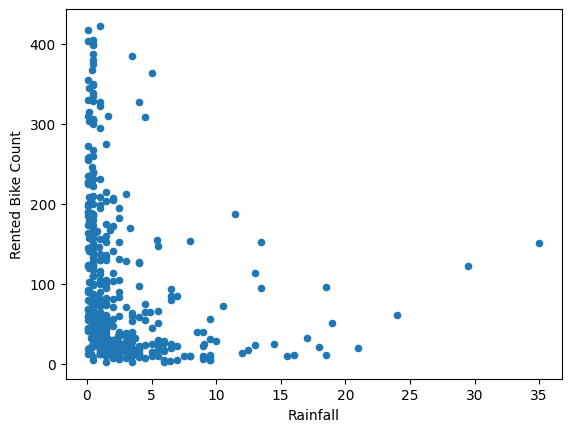

In [159]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('SeoulBikeData_new.csv')

df_rain = df[["Rainfall", "Rented Bike Count"]]

df_rain = df_rain[(df_rain['Rainfall'] != 0) & (df_rain['Rainfall'] > 0)]
df_rain = df_rain[(df_rain['Rented Bike Count'] != 0)]

CQ1 = df_rain["Rented Bike Count"].quantile(0.25)
CQ3 = df_rain["Rented Bike Count"].quantile(0.75)
CIQR = CQ3 - CQ1

coutliers = df_rain["Rented Bike Count"][df_rain["Rented Bike Count"] > CQ3 + CIQR * 1.5]

df_rain["Rented Bike Count"] = df_rain["Rented Bike Count"].loc[~df_rain["Rented Bike Count"].isin(coutliers)]

df_rain = df_rain.dropna()

print(df_rain.corr(), '\n')

df_rain.plot.scatter(x = "Rainfall", y = "Rented Bike Count")
plt.show()

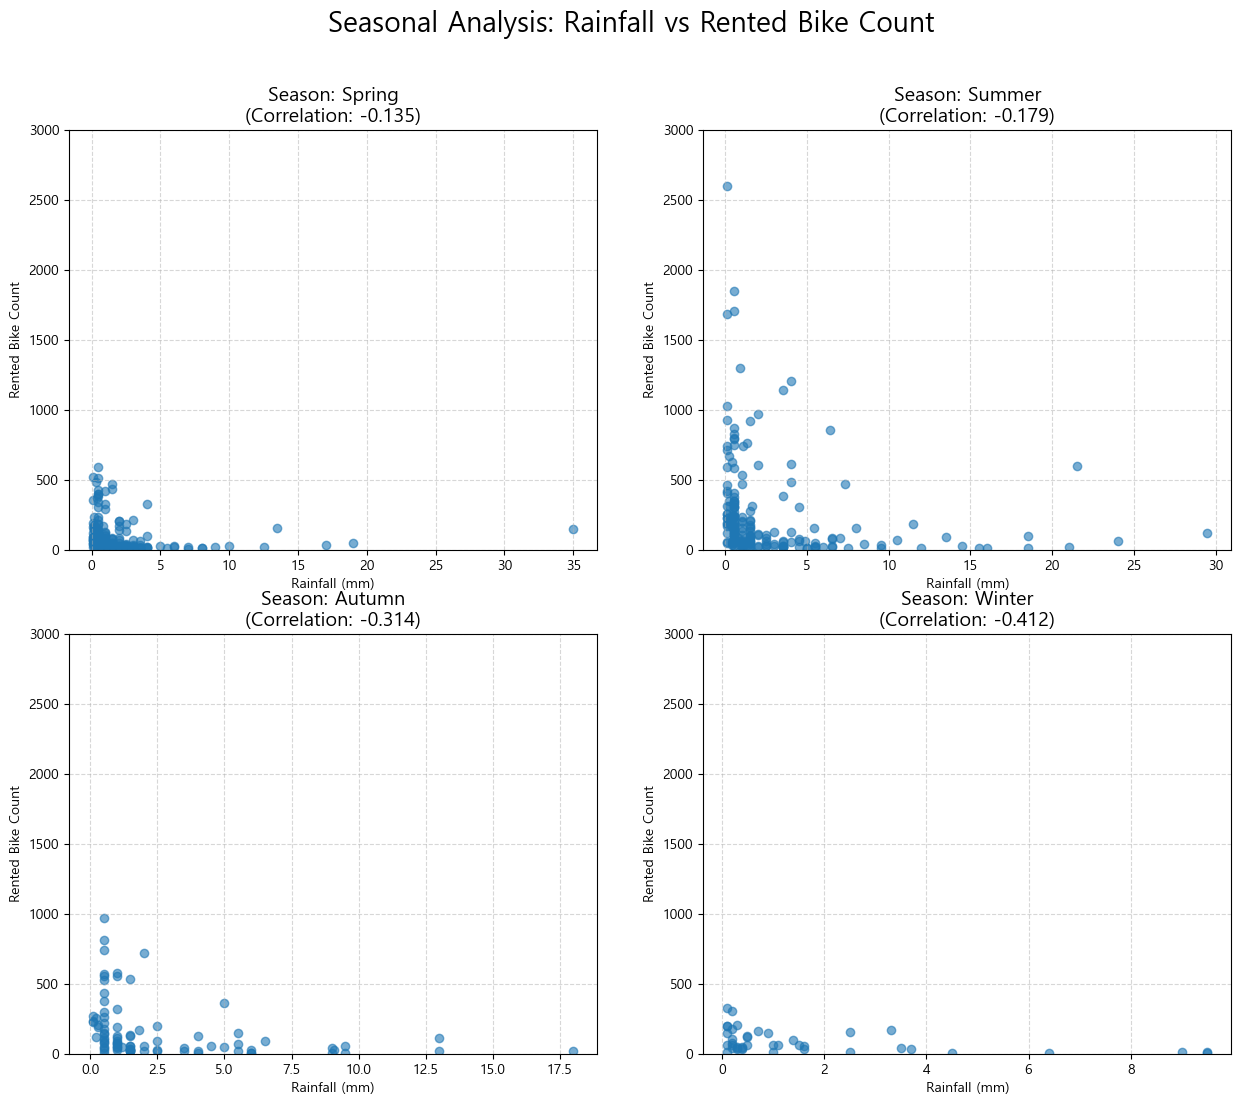

In [193]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('SeoulBikeData_new.csv')
df = df[df['Rented Bike Count'] < 20000]

df_rainy = df[(df['Rainfall'] > 0) & (df['Rented Bike Count'] > 0)].copy()

seasons = ['Spring', 'Summer', 'Autumn', 'Winter']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, season in enumerate(seasons):
    season_data = df_rainy[df_rainy['Seasons'] == season]
    
    axes[i].scatter(season_data['Rainfall'], season_data['Rented Bike Count'], alpha=0.6)
        
    if not season_data.empty:
        corr_val = season_data[['Rainfall', 'Rented Bike Count']].corr().iloc[0, 1]
        axes[i].set_title(f'Season: {season}\n(Correlation: {corr_val:.3f})', fontsize=14)
    else:
        axes[i].set_title(f'Season: {season} (No Data)', fontsize=14)
        
    axes[i].set_xlabel('Rainfall (mm)')
    axes[i].set_ylabel('Rented Bike Count')
    axes[i].set_ylim(0, 3000)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Seasonal Analysis: Rainfall vs Rented Bike Count', fontsize=20)
plt.show()

                   Rainfall  Rented Bike Count
Rainfall           1.000000          -0.147128
Rented Bike Count -0.147128           1.000000 



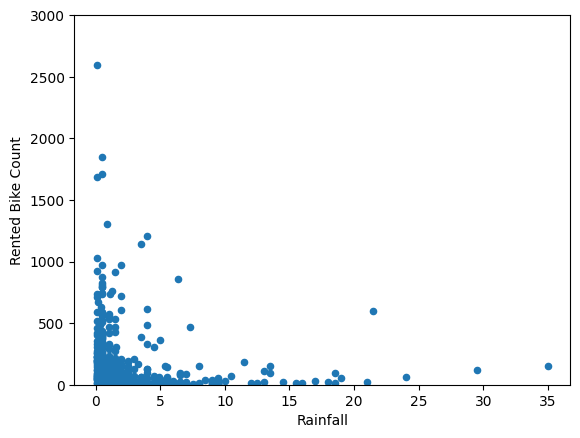

In [170]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('SeoulBikeData_new.csv')
df = df[df['Rented Bike Count'] < 20000]

df_rain = df[["Rainfall", "Rented Bike Count"]].copy()

df_rain = df_rain[(df_rain['Rainfall'] != 0) & (df_rain['Rainfall'] > 0)]
df_rain = df_rain[(df_rain['Rented Bike Count'] != 0)]

print(df_rain.corr(), '\n')

df_rain.plot.scatter(x = "Rainfall", y = "Rented Bike Count")
plt.ylim(0, 3000)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_23112\1093426868.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_23112\1093426868.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_23112\1093426868.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


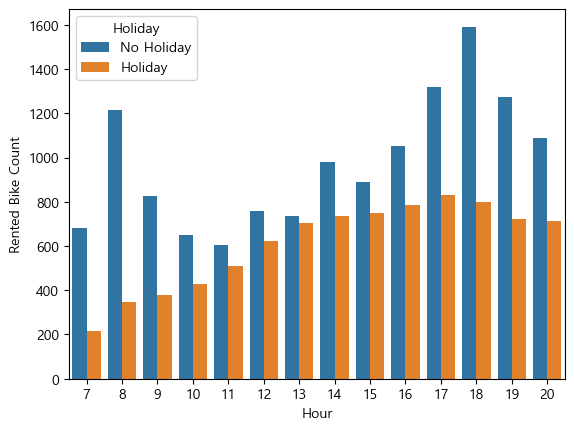

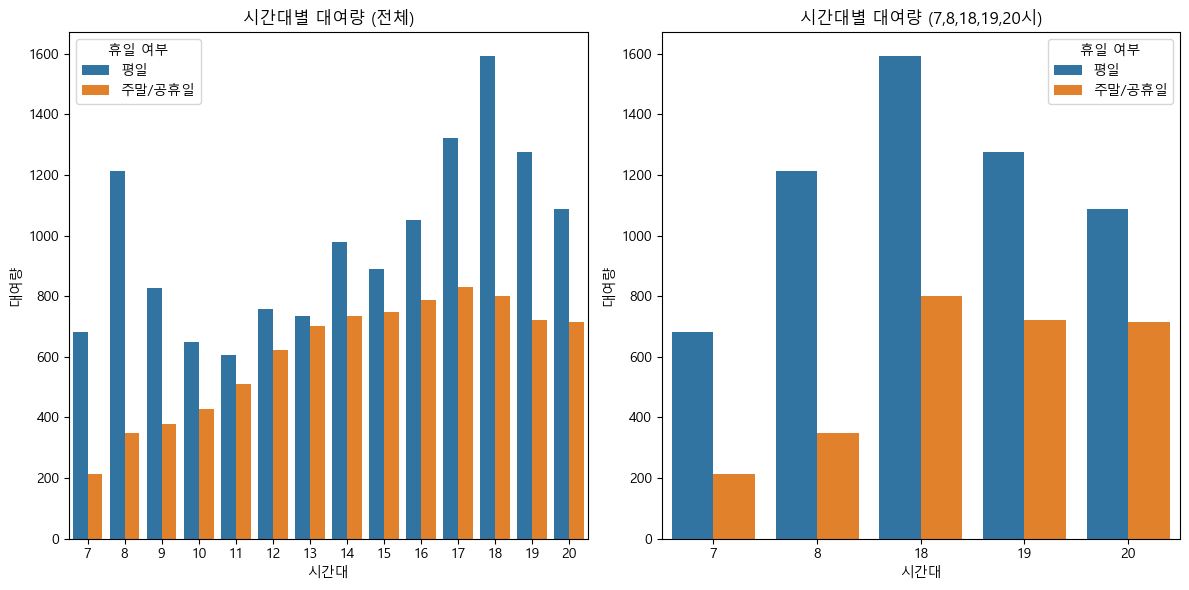

In [189]:
#1
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('SeoulBikeData_new.csv')

sns.barplot(
    data=df,
    x='Hour',
    y='Rented Bike Count',
    hue='Holiday',
    ci=None,
    # x축 시간대 구간 설정
    order=[7, 8,9,10,11,12,13,14,15,16,17,18,19,20]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(
    data=df,
    x='Hour',
    y='Rented Bike Count',
    hue='Holiday',
    ci=None,
    order=[7, 8,9,10,11,12,13,14,15,16,17,18,19,20],
    ax=axes[0]
)   
sns.barplot(
    data=df,
    x='Hour',
    y='Rented Bike Count',
    hue='Holiday',
    ci=None,
    order=[7,8,18,19,20],
    ax=axes[1]
)
# 한국어 깨짐 방지
plt.rc('font', family='Malgun Gothic')
# x y 라벨 한국어 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
axes[0].set_title('시간대별 대여량 (전체)')
axes[0].set_xlabel('시간대')
axes[0].set_ylabel('대여량')
axes[0].legend(title='휴일 여부', labels=['평일', '주말/공휴일'])
axes[1].set_title('시간대별 대여량 (7,8,18,19,20시)')
axes[1].set_xlabel('시간대')
axes[1].set_ylabel('대여량')
axes[1].legend(title='휴일 여부', labels=['평일', '주말/공휴일'])
plt.tight_layout()
plt.show()

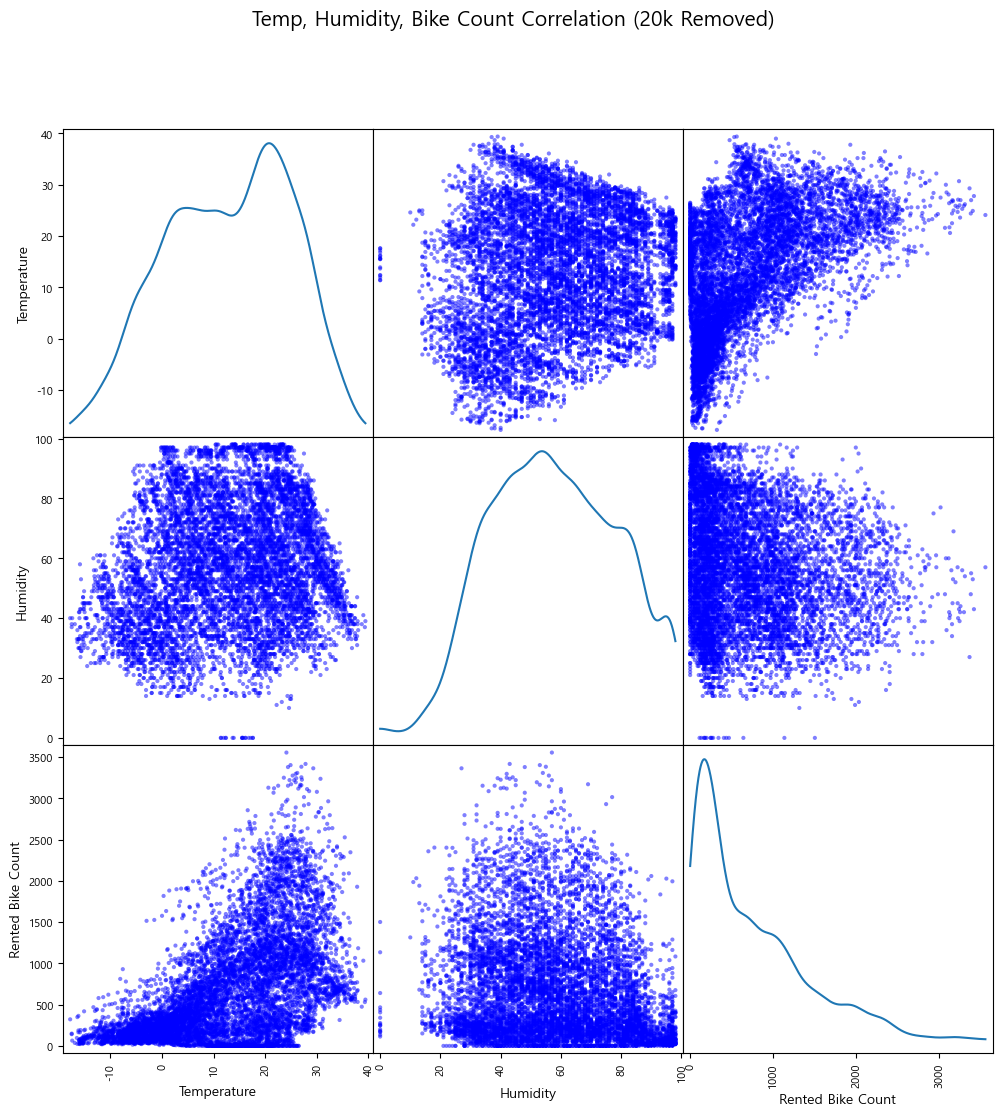

C:\Users\user\AppData\Local\Temp\ipykernel_23112\1498443172.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_res, x='Temp_Bin', y='Rented Bike Count', palette='YlOrRd')


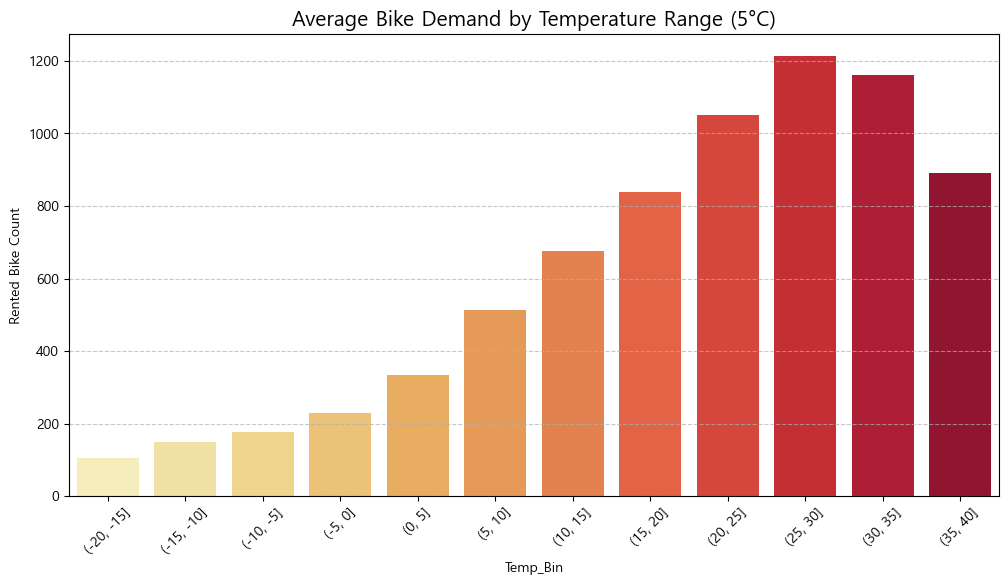

최종 분석에 사용된 데이터 수: 8680개


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# 데이터 로드
df = pd.read_csv('SeoulBikeData_new.csv')

# 1. 이상치 및 오류 데이터 통합 제거
df_clean = df[
    (df['Rented Bike Count'] < 20000) & 
    (df['Temperature'] < 100) & 
    (df['Humidity'] <= 100)
].copy()

# 2. Scatter Matrix (상관관계 매트릭스)
cols = ['Temperature', 'Humidity', 'Rented Bike Count']
scatter_matrix(df_clean[cols], alpha=0.5, figsize=(12, 12), diagonal='kde', color='blue')
plt.suptitle('Temp, Humidity, Bike Count Correlation (20k Removed)', fontsize=15)
plt.show()

# 3. 온도 구간별 평균 대여량 (막대 그래프)
bins = list(range(-20, 41, 5))
df_clean['Temp_Bin'] = pd.cut(df_clean['Temperature'], bins=bins)
temp_res = df_clean.groupby('Temp_Bin', observed=True)['Rented Bike Count'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=temp_res, x='Temp_Bin', y='Rented Bike Count', palette='YlOrRd')
plt.title('Average Bike Demand by Temperature Range (5°C)', fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

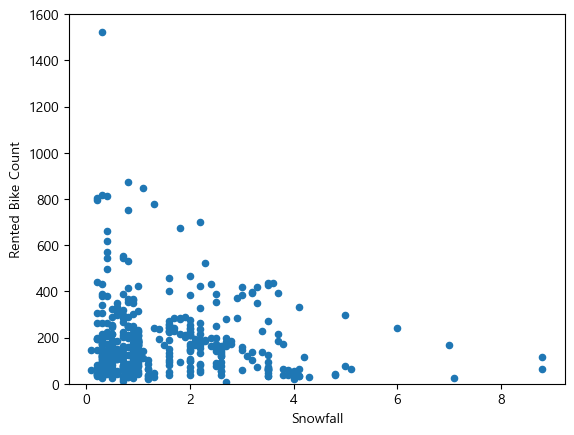

In [185]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('SeoulBikeData_new.csv')
df = df[['Snowfall','Rented Bike Count']]
df = df[df['Snowfall'] != 0.0]
df = df[df['Rented Bike Count'] < 20000]
df_clean = df.dropna()
df_clean.corr()
df_clean.plot.scatter(x='Snowfall', y='Rented Bike Count')
plt.ylim(0, 1600)
plt.show()